Group Members: Nicolas Banatt, Annanya Jain, James McDermott, Yanran Jia

In [1408]:
!python --version

Python 3.12.1


In [1409]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [1410]:
import pandas as pd

In [1411]:
df = pd.read_csv('MergedData_clean.csv')

df.head()

,Participant,ID,Gender,Group,Race,Ethnicity,Assmnt,Avg_Daily_Week_Min,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,...,Age,BMI,RRV_Pgoal,RRV_Agoal,RRVscore,RRVch,oesPos,oesNeg,pretieqPref,pretieqTole
0,407-0001,1,M,0.0,White,Not Hispanic or Latino,baseline,910.0,629.0,256.0,...,32.0,32.5,ellip,read,0.50,0.00,90.0,3.33,30.0,24.0
1,407-0001,1,M,0.0,White,Not Hispanic or Latino,endposttr,824.0,521.0,252.0,...,33.0,31.7,tmill,read,1.00,0.50,91.0,13.33,32.0,23.0
2,407-0001,1,M,0.0,White,Not Hispanic or Latino,pstwash,848.0,579.0,229.0,...,33.0,32.2,tmill,read,0.75,0.25,90.5,8.33,30.0,39.0
3,407-0002,2,M,0.0,White,Not Hispanic or Latino,baseline,680.0,546.0,127.0,...,33.0,32.1,cycle,wrdgms,0.00,0.00,83.0,48.33,26.0,20.0
4,407-0002,2,M,0.0,White,Not Hispanic or Latino,endposttr,622.0,510.0,102.0,...,33.0,32.0,ellip,cwrdpz,0.00,0.00,71.0,46.17,23.0,19.0


In [1412]:
# Change RRVch (our target) to binary label for classification
df["RRV_label"] = (df["RRVch"] > 0).astype(int)

# 1. Extract the baseline rows (one per participant)
baseline = df[df["Assmnt"] == "baseline"][["ID", "RRVscore"]]
baseline = baseline.rename(columns={"RRVscore": "Baseline_RRVscore"})

# 2. Keep only pstwash and endposttr rows
post = df[df["Assmnt"].isin(["pstwash", "endposttr"])]

# 3. Merge baseline RRVscore onto these rows
merged = post.merge(baseline, on="ID", how="left")

# merged now contains:
#   • all pstwash and endposttr rows
#   • baseline RRVscore appended for each participant

df = merged
df.drop(columns=[])

df.head()

,Participant,ID,Gender,Group,Race,Ethnicity,Assmnt,Avg_Daily_Week_Min,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,...,RRV_Pgoal,RRV_Agoal,RRVscore,RRVch,oesPos,oesNeg,pretieqPref,pretieqTole,RRV_label,Baseline_RRVscore
0,407-0001,1,M,0.0,White,Not Hispanic or Latino,endposttr,824.0,521.0,252.0,...,tmill,read,1.00,0.50,91.0,13.330,32.0,23.0,1,0.50
1,407-0001,1,M,0.0,White,Not Hispanic or Latino,pstwash,848.0,579.0,229.0,...,tmill,read,0.75,0.25,90.5,8.330,30.0,39.0,1,0.50
2,407-0002,2,M,0.0,White,Not Hispanic or Latino,endposttr,622.0,510.0,102.0,...,ellip,cwrdpz,0.00,0.00,71.0,46.170,23.0,19.0,0,0.00
3,407-0002,2,M,0.0,White,Not Hispanic or Latino,pstwash,641.0,519.0,117.0,...,cycle,wrdgms,0.00,0.00,77.0,47.250,22.0,19.0,0,0.00
4,407-0003,3,F,0.0,White,Not Hispanic or Latino,pstwash,753.0,434.0,300.0,...,tmill,read,0.75,0.00,91.1,32.335,23.0,27.0,0,0.75


## K-Nearest Neighbors

In [1413]:
from sklearn.preprocessing import MinMaxScaler
# James

knn_df = df.copy()
knn_df = knn_df.dropna(subset=["Baseline_RRVscore"])

knn_df["Assmnt"] = knn_df["Assmnt"].map({
    "endposttr": 6,
    "pstwash": 10
})

knn_df["Gender"] = knn_df["Gender"].map({
    "M": 0,
    "F": 1
})

knn_df["RRV_Pgoal"] = knn_df["RRV_Pgoal"].map({
    "tmill": 0,
    "ellip": 1,
    "cycle": 2
})

knn_df["RRV_Agoal"] = knn_df["RRV_Agoal"].map({
    "read": 0,
    "wrdgms": 1,
    "cwrdpz": 2
})

attr = knn_df.drop(columns = ['RRVscore','RRV_Pgoal','RRV_Agoal','Gender','Group','Height','Age','BMI','Participant','ID','Race','Ethnicity','Avg_Daily_Week_Min','RRVch','oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole','RRV_label'])  # features 'oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'
target = knn_df['RRV_label']  # target variable
attr.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,0.50
1,10,579.0,229.0,40.0,0.0,0.0,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0.75


In [1414]:
scaler = MinMaxScaler()
attr = pd.DataFrame(scaler.fit_transform(attr), columns=attr.columns)
attr.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
0,0.0,0.277690,0.585714,0.783333,0.571429,0.0,0.50
1,1.0,0.323576,0.530952,0.666667,0.000000,0.0,0.50
2,0.0,0.268987,0.228571,0.183333,0.000000,0.0,0.00
3,1.0,0.276108,0.264286,0.083333,0.000000,0.0,0.00
4,1.0,0.208861,0.700000,0.300000,0.000000,0.0,0.75


In [1415]:
from sklearn.model_selection._split import train_test_split

attr_train, attr_test, target_train,target_test  = train_test_split(attr, target, test_size = 0.3, shuffle = True)
target_train.head()
attr_train.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
5,0.0,0.543513,0.430952,0.533333,0.285714,0.0,0.400000
90,1.0,0.821994,0.500000,0.250000,0.000000,0.0,0.000000
24,0.0,0.288766,0.673810,0.750000,0.000000,0.0,0.666667
46,0.0,0.341772,0.347619,0.550000,0.000000,0.0,1.000000
17,0.0,0.232595,0.300000,0.366667,0.000000,0.0,0.500000


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [5, 10, 3]
 
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(attr_train, target_train)
    target_pred = knn.predict(attr_test)
    accuracy = accuracy_score(target_test,target_pred ) 
    print(f'Accuracy of model with k = {k}: {accuracy}')
    print('')

Accuracy of model with k = 3: 0.7297297297297297

Accuracy of model with k = 5: 0.7027027027027027

Accuracy of model with k = 10: 0.6486486486486487



In [1417]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(target_test, target_pred)

print('Confusion Matrix')
print(confusion_matrix(target_test, target_pred))
print()
print('Accuracy score')
print(accuracy_score(target_test, target_pred))
print()
print('Classification Report')
print(classification_report(target_test, target_pred))

Confusion Matrix
[[21  3]
 [10  3]]

Accuracy score
0.6486486486486487

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.88      0.76        24
           1       0.50      0.23      0.32        13

    accuracy                           0.65        37
   macro avg       0.59      0.55      0.54        37
weighted avg       0.62      0.65      0.61        37



In [1418]:
test_actual=attr_test
test_actual['target_pred']=target_pred
test_actual['test_actual']=target_test
test_actual.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore,target_pred,test_actual
77,1.0,0.267405,0.526190,0.600000,0.000000,0.000000,0.50,0,0.0
70,1.0,0.491297,0.430952,0.433333,0.000000,0.000000,0.75,0,NaN
102,1.0,0.863924,0.264286,0.083333,0.000000,0.000000,1.00,0,NaN
116,1.0,0.679589,0.700000,0.266667,0.142857,0.000000,0.75,0,0.0
114,1.0,0.759494,0.550000,0.466667,0.285714,0.428571,0.60,0,NaN


In [1419]:
freq_table =pd.crosstab( test_actual['test_actual'], test_actual['target_pred'])
print("Confusion Matrix")
print(freq_table)

Confusion Matrix
target_pred  0  1
test_actual      
0.0          9  3
1.0          7  1


[Text(0, 0.5, '0(No_Increase)'), Text(0, 1.5, '1(Increase_Motiv)')]

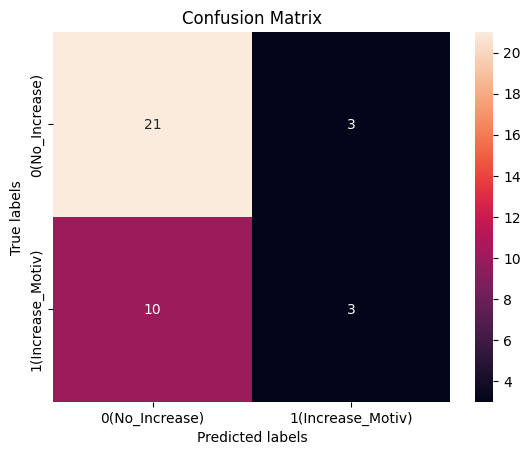

In [1420]:
import seaborn as sns
import matplotlib.pyplot as plt     

ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])
ax.yaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])

## CART (Nicolas)

In [ ]:
cart_attr = df.drop(columns = ["Participant", "ID"])

## Naive Bayes

In [1421]:
# James


## Random Forest

In [1422]:
# James


## Artificial Neural Network (Nicolas)

In [18]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.10.7-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.0-cp313-cp313-win_amd64.whl.metadata (115 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.7-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.0-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn import metrics

In [ ]:
# Split target variable and attributes
attr = df.drop(columns=['id', 'diagnosis'])
target = df['diagnosis']

## Hierarchical Clustering

## K-Means Clustering

## Support Vector Machine

## MiniSOM